<a href="https://colab.research.google.com/github/madhusudhanreddyd-ux/NASCOM_FDP/blob/main/NASSCOM__day_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Core imports for the whole lab
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
print('Setup complete. pandas', pd.__version__)

Setup complete. pandas 2.2.2


In [ ]:
# -----------------------------------------------------------
# A SMALL, ALREADY-CLEAN DATASET (Part 1 did the cleaning)
# -----------------------------------------------------------
# Mixed columns: an unordered category (city), an ordered category
# (size), two numeric features on very different scales, and a target.
df = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],   # target
})
df

,city,size,age,income,bought
0,pune,small,25,38000,0
1,delhi,large,41,92000,1
2,mumbai,medium,33,55000,0
3,pune,medium,29,47000,0
4,delhi,small,52,120000,1
5,mumbai,large,38,76000,1
6,pune,large,46,88000,1
7,delhi,small,22,41000,0


In [ ]:
# 'city' has no natural order -> one 0/1 column per category
city_ohe = pd.get_dummies(df['city'], prefix='city').astype(int)
city_ohe

,city_delhi,city_mumbai,city_pune
0,0,0,1
1,1,0,0
2,0,1,0
3,0,0,1
4,1,0,0
5,0,1,0
6,0,0,1
7,1,0,0


In [ ]:
# 'size' has a real order: small < medium < large -> map to 0,1,2
size_order = {'small': 0, 'medium': 1, 'large': 2}
df['size_code'] = df['size'].map(size_order)
df[['size', 'size_code']]

,size,size_code
0,small,0
1,large,2
2,medium,1
3,medium,1
4,small,0
5,large,2
6,large,2
7,small,0


In [ ]:
city_ohe1 = pd.get_dummies(df['city']).astype(int)
city_ohe1

,delhi,mumbai,pune
0,0,0,1
1,1,0,0
2,0,1,0
3,0,0,1
4,1,0,0
5,0,1,0
6,0,0,1
7,1,0,0


In [ ]:
df

,city,size,age,income,bought,size_code
0,pune,small,25,38000,0,0
1,delhi,large,41,92000,1,2
2,mumbai,medium,33,55000,0,1
3,pune,medium,29,47000,0,1
4,delhi,small,52,120000,1,0
5,mumbai,large,38,76000,1,2
6,pune,large,46,88000,1,2
7,delhi,small,22,41000,0,0


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
# 1. One-hot encode the 'city' column
df = pd.get_dummies(df, columns=['city'], dtype=int)



In [ ]:
# 2. Ordinal encode the 'size' column using the specified order
encoder = OrdinalEncoder(categories=[list(size_order.keys())])
df["size_code"] = encoder.fit_transform(df[["size"]]).astype(int)

In [ ]:
df

,size,age,income,bought,size_code,city_delhi,city_mumbai,city_pune
0,small,25,38000,0,0,0,0,1
1,large,41,92000,1,2,1,0,0
2,medium,33,55000,0,1,0,1,0
3,medium,29,47000,0,1,0,0,1
4,small,52,120000,1,0,1,0,0
5,large,38,76000,1,2,0,1,0
6,large,46,88000,1,2,0,0,1
7,small,22,41000,0,0,1,0,0


In [ ]:
print(df[['age', 'income']].describe().loc[['min', 'max', 'mean']])

        age    income
min   22.00   38000.0
max   52.00  120000.0
mean  35.75   69625.0


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

num = df[['age', 'income']]

z = StandardScaler().fit_transform(num)        # mean 0, std 1
m = MinMaxScaler().fit_transform(num)          # range [0, 1]

print('Standardised (mean~0, std~1):')
print(pd.DataFrame(z, columns=['age', 'income']).round(2).head(3))
print('\nMin-Max (range 0..1):')
print(pd.DataFrame(m, columns=['age', 'income']).round(2).head(3))

Standardised (mean~0, std~1):
    age  income
0 -1.10   -1.16
1  0.54    0.82
2 -0.28   -0.54

Min-Max (range 0..1):
    age  income
0  0.10    0.00
1  0.63    0.66
2  0.37    0.21


In [ ]:
# Confirm StandardScaler results
print('\nStandardized data statistics:')
print(pd.DataFrame(z, columns=['age', 'income']).describe().loc[['mean', 'std']].round(2))


Standardized data statistics:
       age  income
mean  0.00   -0.00
std   1.07    1.07


In [ ]:
# Confirm MinMaxScaler results
print('\nMin-Max scaled data statistics:')
print(pd.DataFrame(m, columns=['age', 'income']).describe().loc[['min', 'max']].round(2))


Min-Max scaled data statistics:
     age  income
min  0.0     0.0
max  1.0     1.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['age', 'income']]
y = df['bought']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # FIT + transform on train
X_test_s  = scaler.transform(X_test)        # only TRANSFORM on test
print('train rows:', X_train.shape[0], '| test rows:', X_test.shape[0])
print('scaler learned mean from TRAIN only:', scaler.mean_.round(1))

train rows: 6 | test rows: 2
scaler learned mean from TRAIN only: [3.45e+01 6.90e+04]


In [ ]:
# 1a. WRONG: fit on ALL data, then split (leakage!)
wrong_mean = StandardScaler().fit(X).mean_

# 1b. RIGHT: fit on TRAIN only
right_mean = StandardScaler().fit(X_train).mean_

print('fit-on-all mean :', wrong_mean.round(1))
print('fit-on-train mean:', right_mean.round(1))

# 2. Why fitting on all data is a problem: ...   (write your answer)

fit-on-all mean : [3.5800e+01 6.9625e+04]
fit-on-train mean: [3.45e+01 6.90e+04]


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. COMBINE & BIN EXISTING COLUMNS
# -----------------------------------------------------------

fe = df.copy()
# combine: income per year of age (a crude 'earning rate')
fe['income_per_age'] = (fe['income'] / fe['age']).round(0)
# bin: turn continuous age into life-stage buckets
fe['age_group'] = pd.cut(fe['age'], bins=[0, 30, 45, 100],
                         labels=['young', 'mid', 'senior'])
fe[['age', 'income', 'income_per_age', 'age_group']]

,age,income,income_per_age,age_group
0,25,38000,1520.0,young
1,41,92000,2244.0,mid
2,33,55000,1667.0,mid
3,29,47000,1621.0,young
4,52,120000,2308.0,senior
5,38,76000,2000.0,mid
6,46,88000,1913.0,senior
7,22,41000,1864.0,young


In [ ]:
# -----------------------------------------------------------
# 🔹 4B. EXTRACT FROM A DATE
# -----------------------------------------------------------

dates = pd.to_datetime(['2024-01-06', '2024-03-15', '2024-07-21', '2024-12-25'])
d = pd.DataFrame({'date': dates})
d['day_of_week'] = d['date'].dt.day_name()   # Monday, Tuesday, ...
d['month']       = d['date'].dt.month
d['is_weekend']  = d['date'].dt.dayofweek >= 5
d

,date,day_of_week,month,is_weekend
0,2024-01-06,Saturday,1,True
1,2024-03-15,Friday,3,False
2,2024-07-21,Sunday,7,True
3,2024-12-25,Wednesday,12,False


In [ ]:
ex = df.copy()


In [ ]:
# 1. high_earner flag (income > median)
median_income = fe['income'].median()
fe['high_earner'] = (fe['income'] > median_income).astype(int)

In [ ]:
# 2. bin income into 3 buckets with pd.cut
fe['income_bucket'] = pd.cut(fe['income'], bins=3, labels=['low', 'medium', 'high'])


In [ ]:
# 3. show income + the new columns
fe[['income', 'high_earner', 'income_bucket']]

,income,high_earner,income_bucket
0,38000,0,low
1,92000,1,medium
2,55000,0,low
3,47000,0,low
4,120000,1,high
5,76000,1,medium
6,88000,1,medium
7,41000,0,low


In [ ]:
df

,size,age,income,bought,size_code,city_delhi,city_mumbai,city_pune
0,small,25,38000,0,0,0,0,1
1,large,41,92000,1,2,1,0,0
2,medium,33,55000,0,1,0,1,0
3,medium,29,47000,0,1,0,0,1
4,small,52,120000,1,0,1,0,0
5,large,38,76000,1,2,0,1,0
6,large,46,88000,1,2,0,0,1
7,small,22,41000,0,0,1,0,0


In [75]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

num_cols = ['age', 'income']
# Update cat_cols as requested by the user
cat_cols = ['city_delhi', 'city_mumbai', 'city_pune', 'size']

# scale the numbers, one-hot the categories — all in one object
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])
pipe = Pipeline([('prep', pre), ('model', LogisticRegression(max_iter=1000))])
print(pipe)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'income']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city_delhi', 'city_mumbai',
                                                   'city_pune', 'size'])])),
                ('model', LogisticRegression(max_iter=1000))])


In [76]:
X = df[num_cols + cat_cols]
y = df['bought']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

pipe.fit(X_train, y_train)        # preprocessing fitted on TRAIN only — no leakage
acc = pipe.score(X_test, y_test)  # transforms test with train-fitted steps
print('Test accuracy:', round(acc, 2))
print('(small toy dataset — the point is the leak-free workflow, not the score)')

Test accuracy: 1.0
(small toy dataset — the point is the leak-free workflow, not the score)


In [77]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

#Example:
#Consider two features: age (20–60) and salary (20,000–200,000).
#Without scaling, salary will dominate age due to its larger values.

data = np.array([[25, 50000],
                 [35, 100000],
                 [45, 150000]])

In [78]:
# Standardization
standardized = StandardScaler().fit_transform(data)

print("Standardized:\n", standardized)



Standardized:
 [[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


In [79]:
# Normalization
normalized = MinMaxScaler().fit_transform(data)
print("Normalized:\n", normalized)

Normalized:
 [[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


## Matplotlib

In [80]:


# -----------------------------------------------------------
# 🧳 PRACTICAL: Getting Started with matplotlib Library
# -----------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

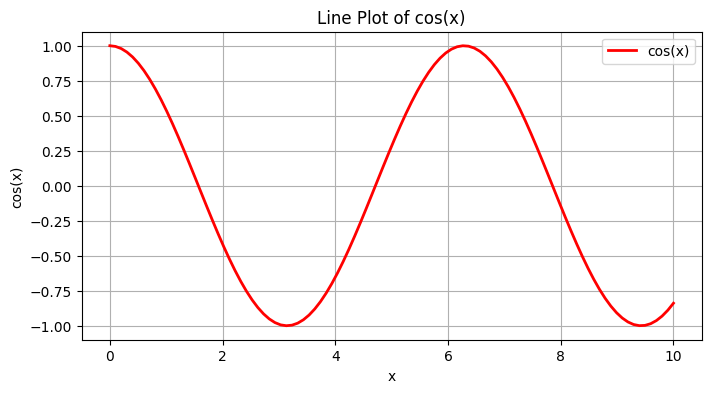

In [85]:
# Create a simple line plot for sin(x)
x = np.linspace(0, 10, 100)
y = np.cos(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label='cos(x)', color='red', linewidth=2)
plt.title('Line Plot of cos(x)')
plt.xlabel('x')
plt.ylabel('cos(x)')
plt.grid(True)
plt.legend()
plt.show()

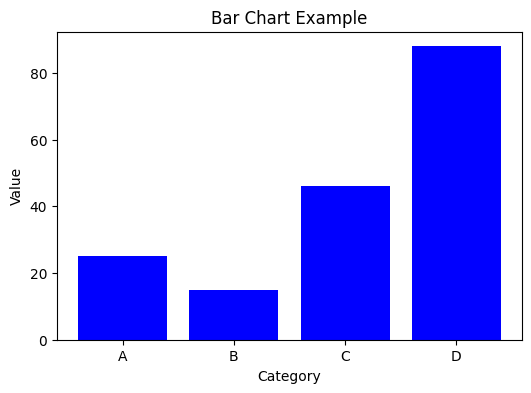

In [87]:
# Simple bar chart with categories and values
categories = ['A', 'B', 'C', 'D']
values = [25, 15, 46, 88]

plt.figure(figsize=(6, 4))
plt.bar(categories, values, color='blue')
plt.title('Bar Chart Example')
plt.xlabel('Category')
plt.ylabel('Value')
plt.show()

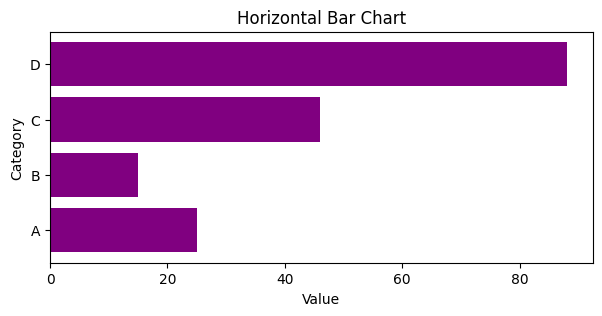

In [92]:
# Display the same bar chart horizontally
plt.figure(figsize=(7, 3))
plt.barh(categories, values, color='purple')
plt.title('Horizontal Bar Chart')
plt.xlabel('Value')
plt.ylabel('Category')
plt.show()

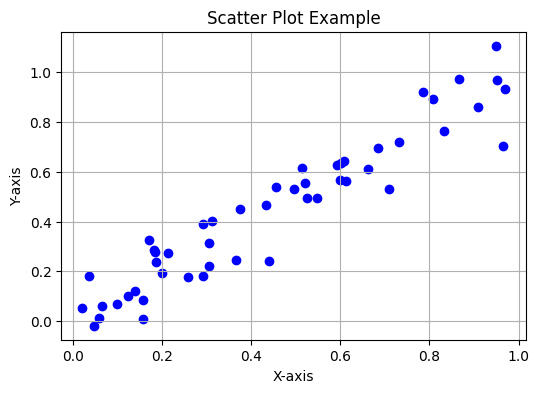

In [96]:
# Scatter plot to show relationship with noise
np.random.seed(42)
x = np.random.rand(50)
y = x + np.random.normal(0, 0.1, 50)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue')
plt.title('Scatter Plot Example')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid(True)
plt.show()

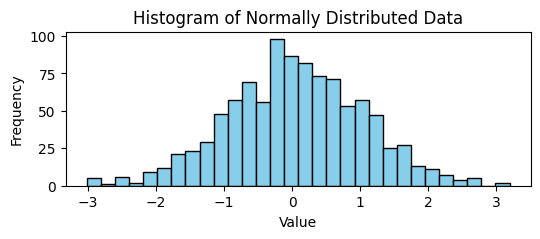

In [98]:
data = np.random.randn(1000)

plt.figure(figsize=(6, 2))
plt.hist(data, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Normally Distributed Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

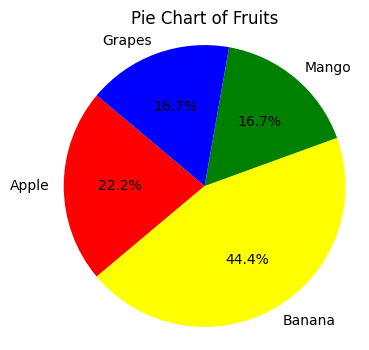

In [102]:
# Pie chart to show proportions of fruit types
sizes = [20, 40, 15, 15]
labels = ['Apple', 'Banana', 'Mango', 'Grapes']
colors = ['red', 'yellow', 'green', 'blue']

plt.figure(figsize=(4, 4))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of Fruits')
plt.axis('equal')
plt.show()

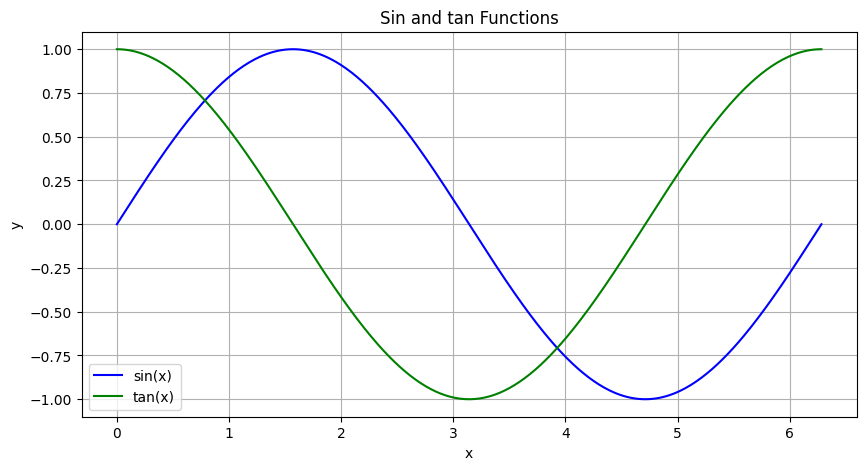

In [105]:
# Plotting sin(x) and cos(x) in a single figure
x = np.linspace(0, 2 * np.pi, 400)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y1, label='sin(x)', color='blue')
plt.plot(x, y2, label='tan(x)', color='green')
plt.title('Sin and tan Functions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

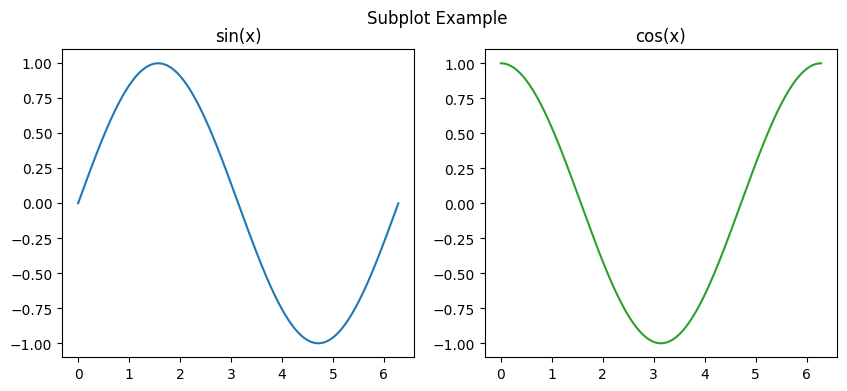

In [106]:
# Using subplots to display multiple charts in one window
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(x, y1, 'tab:blue')
axs[0].set_title('sin(x)')
axs[1].plot(x, y2, 'tab:green')
axs[1].set_title('cos(x)')
plt.suptitle('Subplot Example')
plt.show()

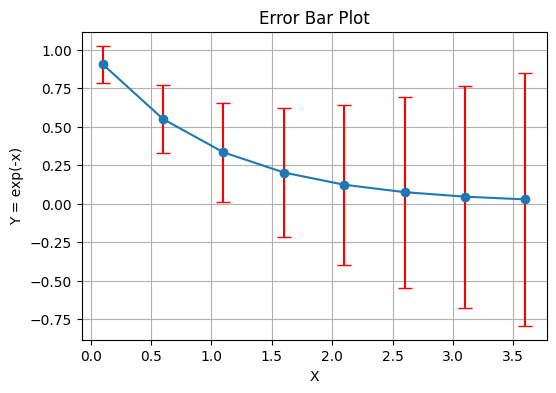

In [107]:
# Error bar plot to show uncertainty in measurements
x = np.arange(0.1, 4, 0.5)
y = np.exp(-x)
error = 0.1 + 0.2 * x

plt.figure(figsize=(6, 4))
plt.errorbar(x, y, yerr=error, fmt='-o', ecolor='red', capsize=5)
plt.title('Error Bar Plot')
plt.xlabel('X')
plt.ylabel('Y = exp(-x)')
plt.grid(True)
plt.show()

# Seaborn

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set seaborn theme
sns.set_theme(style="darkgrid")

In [109]:
# Load built-in "tips" dataset for demonstration
tips = sns.load_dataset("tips")
print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


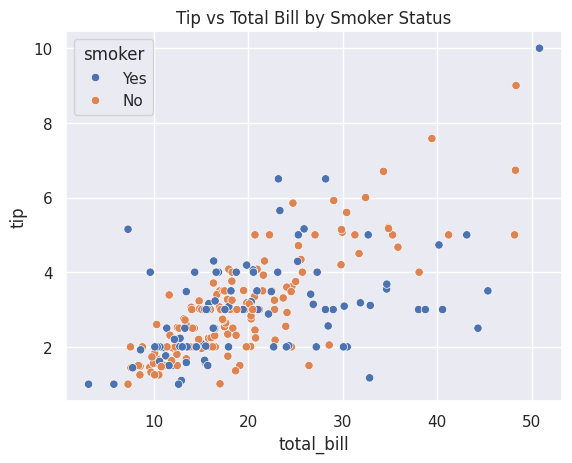

In [110]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="smoker")
plt.title("Tip vs Total Bill by Smoker Status")
plt.show()

/tmp/ipykernel_2233/1455336764.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=tips, x="day", y="tip", ci="sd", palette="muted")
/tmp/ipykernel_2233/1455336764.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x="day", y="tip", ci="sd", palette="muted")


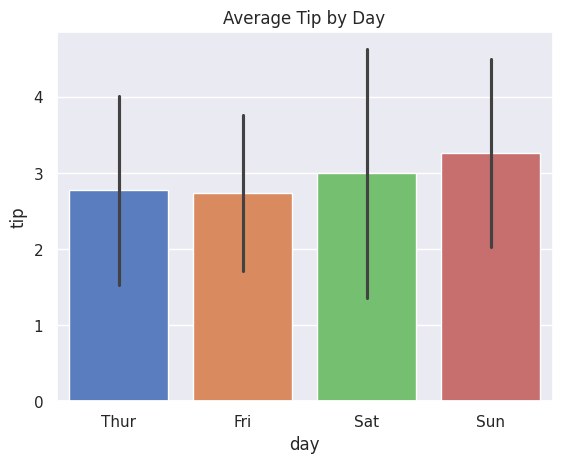

In [111]:
sns.barplot(data=tips, x="day", y="tip", ci="sd", palette="muted")
plt.title("Average Tip by Day")
plt.show()

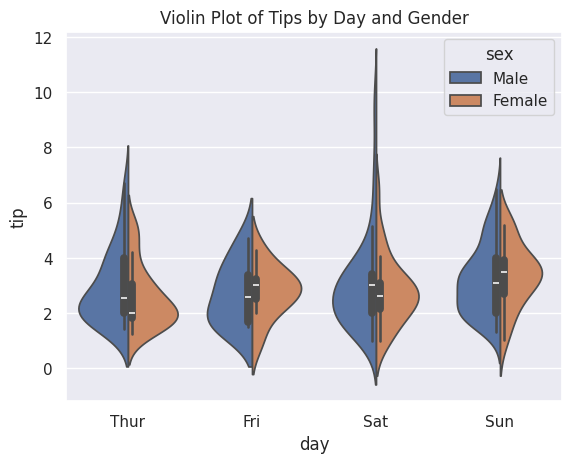

In [112]:
sns.violinplot(data=tips, x="day", y="tip", hue="sex", split=True)
plt.title("Violin Plot of Tips by Day and Gender")
plt.show()

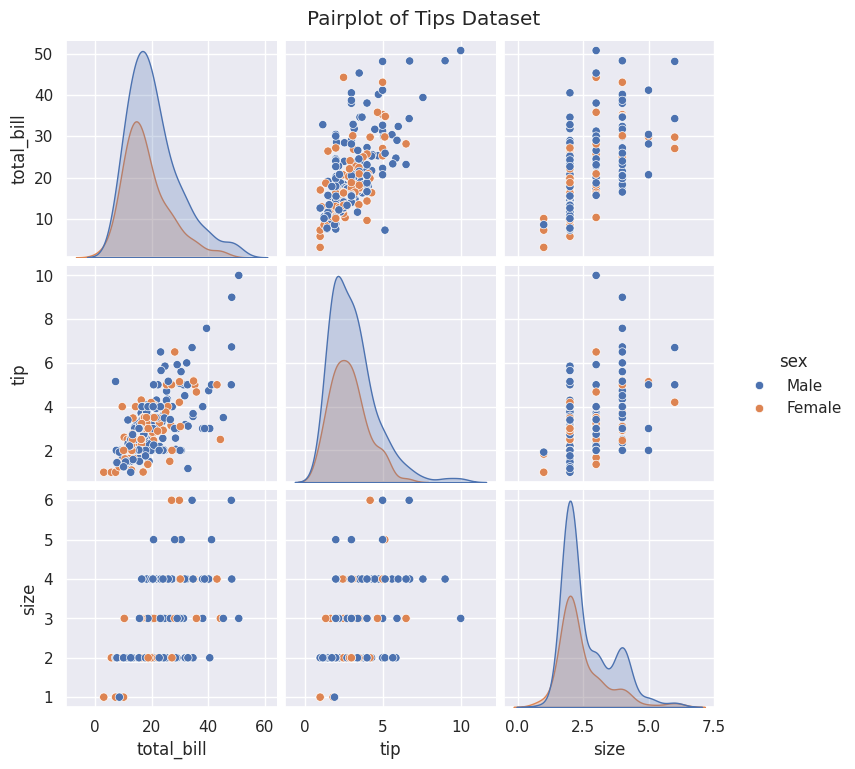

In [113]:
sns.pairplot(tips, hue="sex")
plt.suptitle("Pairplot of Tips Dataset", y=1.02)
plt.show()

In [116]:
from wordcloud import WordCloud
from collections import Counter

In [117]:
# Simulate a list of review texts
review_texts = [
    "Great food and great service",
    "Food was amazing, especially the dessert",
    "Service was slow but food was good",
    "The ambiance was perfect",
    "Not happy with service but liked the food",
    "Dessert and coffee were excellent"
]

# Combine all reviews into one string
all_words = " ".join(review_texts).lower().split()
word_counts = Counter(all_words)

# Create a DataFrame from the word counts
word_freq_df = pd.DataFrame(word_counts.items(), columns=['word', 'frequency'])


/tmp/ipykernel_2233/2792827115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_freq_df.sort_values(by="frequency", ascending=False), x="word", y="frequency", palette="viridis")


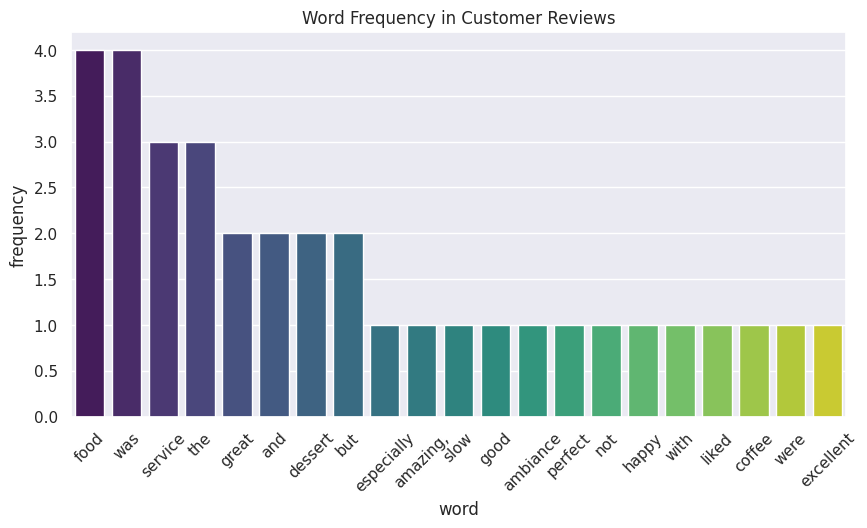

In [118]:
# Bar plot of most common words
plt.figure(figsize=(10, 5))
sns.barplot(data=word_freq_df.sort_values(by="frequency", ascending=False), x="word", y="frequency", palette="viridis")
plt.title("Word Frequency in Customer Reviews")
plt.xticks(rotation=45)
plt.show()

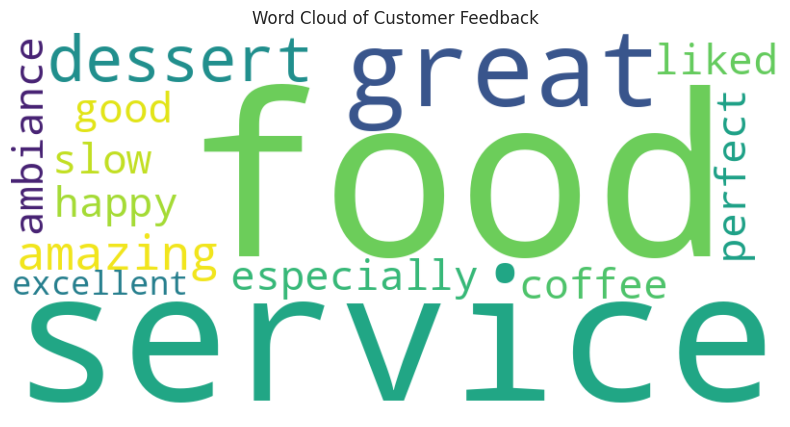

In [119]:
# Create and display a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(all_words))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Customer Feedback")
plt.show()

# Matplotlib_&_Seaborn_Exercise

In [120]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Intermediate Matplotlib & Seaborn Exercise ---")
print("Complete each task by writing the requested plotting code.")
print("Focus on proper labeling, titles, and drawing insights.")
print("--------------------------------------------------")

--- Intermediate Matplotlib & Seaborn Exercise ---
Complete each task by writing the requested plotting code.
Focus on proper labeling, titles, and drawing insights.
--------------------------------------------------


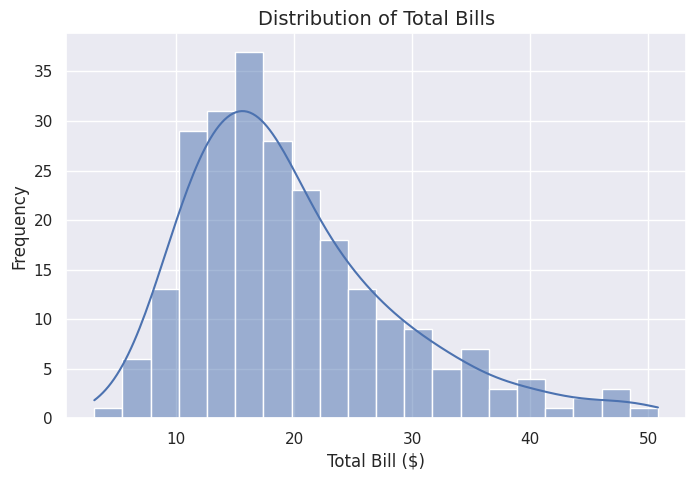

In [121]:
# Load the dataset
tips = sns.load_dataset("tips")

# Create the histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=tips, x="total_bill", bins=20, kde=True)

# Add titles and labels
plt.title("Distribution of Total Bills", fontsize=14)
plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Show the plot
plt.show()

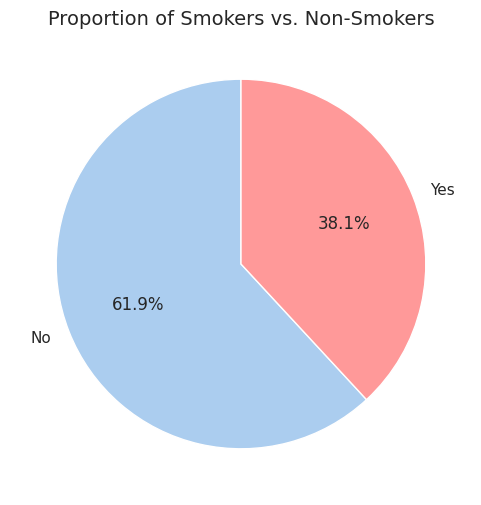

In [122]:
# Count the occurrences of each smoker status
smoker_counts = tips["smoker"].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    smoker_counts,
    labels=smoker_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#abcdef", "#ff9999"],
)

# Add title
plt.title("Proportion of Smokers vs. Non-Smokers", fontsize=14)

# Show the plot
plt.show()

/tmp/ipykernel_2233/2197410066.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x="day", y="total_bill", errorbar=None, palette="Blues_d")


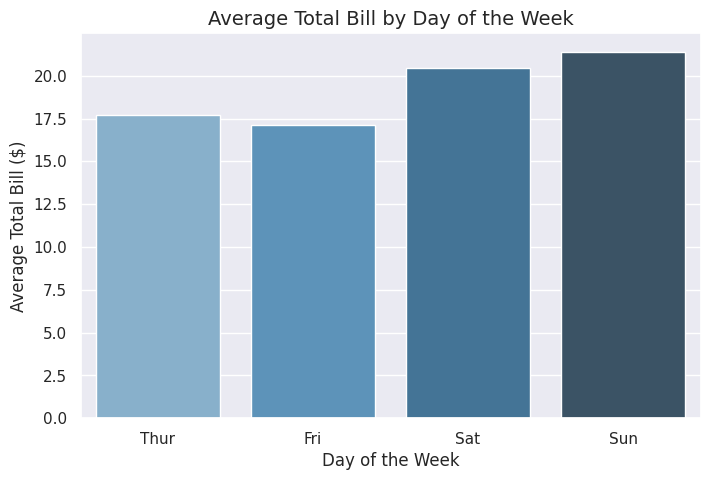

In [123]:
plt.figure(figsize=(8, 5))
sns.barplot(data=tips, x="day", y="total_bill", errorbar=None, palette="Blues_d")

# Add titles and labels
plt.title("Average Total Bill by Day of the Week", fontsize=14)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Average Total Bill ($)", fontsize=12)

# Show the plot
plt.show()

/tmp/ipykernel_2233/3080897075.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x="tip", y="time", errorbar=None, palette="Dark2")


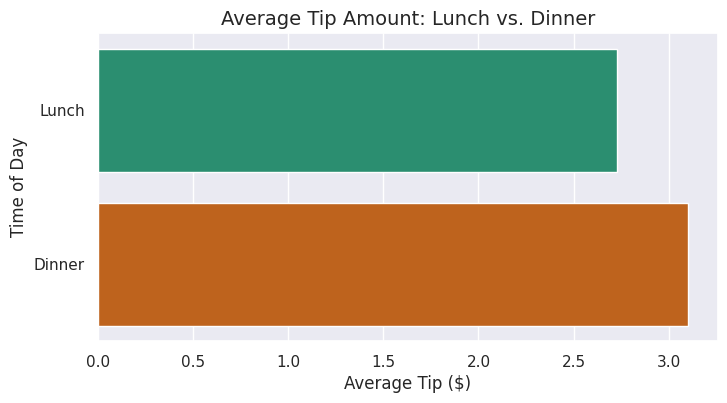

In [124]:
plt.figure(figsize=(8, 4))
sns.barplot(data=tips, x="tip", y="time", errorbar=None, palette="Dark2")

# Add titles and labels
plt.title("Average Tip Amount: Lunch vs. Dinner", fontsize=14)
plt.xlabel("Average Tip ($)", fontsize=12)
plt.ylabel("Time of Day", fontsize=12)

# Show the plot
plt.show()

# Feature Engineering

In [131]:
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')


import pandas as pd, numpy as np
import matplotlib.pyplot as plt

SNAPSHOT = pd.Timestamp('2024-06-30')   # the day the data was pulled

cust = pd.read_csv('ecommerce_customers.csv',
                   parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
tx = pd.read_excel('transactions.xlsx', parse_dates=['order_date'])
print('customers:', cust.shape, '| transactions:', tx.shape)
tx.head()

Found the provided dataset files.
customers: (2500, 15) | transactions: (8152, 4)


,customer_id,order_date,amount,category
0,CUST00003,2023-05-22,39.17,Fashion
1,CUST00004,2022-07-02,2.74,Home
2,CUST00005,2022-09-18,26.27,Electronics
3,CUST00005,2023-04-07,33.48,Fashion
4,CUST00005,2023-08-04,56.41,Fashion


In [132]:
rfm = tx.groupby('customer_id').agg(
    frequency=('amount', 'size'),                 # F: how many orders
    monetary=('amount', 'sum'),                   # M: total spent
    avg_order_value=('amount', 'mean'),           # typical basket
    first_order=('order_date', 'min'),            # Add first_order here
    last_order=('order_date', 'max'),
    n_categories=('category', 'nunique'),         # breadth of interest
).reset_index()
# R: recency = days since last order, measured from the snapshot
rfm['recency_days'] = (SNAPSHOT - rfm['last_order']).dt.days
rfm[['customer_id', 'frequency', 'monetary', 'avg_order_value',
     'recency_days', 'n_categories']].head()


# -----------------------------------------------------------
# 🔹 1B. MERGE THE NEW FEATURES BACK ONTO THE CUSTOMER TABLE
# -----------------------------------------------------------
df = cust.merge(rfm.drop(columns='last_order'), on='customer_id', how='left')
# customers with no transactions -> fill sensible defaults
df['frequency'] = df['frequency'].fillna(0)
df['monetary'] = df['monetary'].fillna(0)
df['n_categories'] = df['n_categories'].fillna(0)
# never ordered -> recency is 'infinitely' stale: cap at customer tenure
df['recency_days'] = df['recency_days'].fillna(9999)
print('Merged shape:', df.shape)
df[['customer_id', 'frequency', 'monetary', 'recency_days', 'is_churned']].head()

Merged shape: (2500, 21)


,customer_id,frequency,monetary,recency_days,is_churned
0,CUST00001,0.0,0.00,9999.0,0
1,CUST00002,0.0,0.00,9999.0,1
2,CUST00003,1.0,39.17,405.0,0
3,CUST00004,1.0,2.74,729.0,0
4,CUST00005,4.0,133.80,15.0,0


In [133]:
rfm['active_span'] = (rfm['last_order'] - rfm['first_order']).dt.days

# Calculate avg_days_between_orders, guarding against divide-by-zero
rfm['avg_days_between_orders'] = np.where(
    rfm['frequency'] > 1,
    rfm['active_span'] / (rfm['frequency'] - 1),
    np.nan  # For customers with 0 or 1 order, the average is undefined
)

# Merge these new features into df
df = df.merge(rfm[['customer_id', 'active_span', 'avg_days_between_orders']],
              on='customer_id', how='left')

# Fill NaN values for new columns for customers with no orders
df['active_span'] = df['active_span'].fillna(0)
df['avg_days_between_orders'] = df['avg_days_between_orders'].fillna(0) # Or another suitable default

display(df[['customer_id', 'frequency', 'active_span', 'avg_days_between_orders', 'is_churned']].head())

,customer_id,frequency,active_span,avg_days_between_orders,is_churned
0,CUST00001,0.0,0.0,0.0,0
1,CUST00002,0.0,0.0,0.0,1
2,CUST00003,1.0,0.0,0.0,0
3,CUST00004,1.0,0.0,0.0,0
4,CUST00005,4.0,636.0,212.0,0


skew before: 1.73
skew after : -1.12


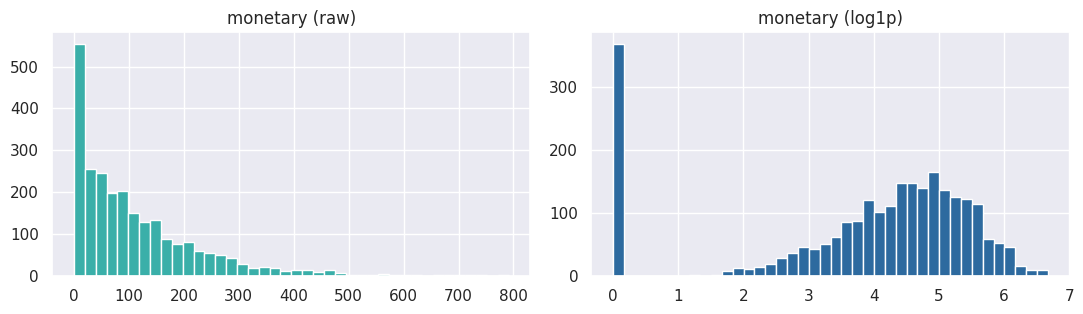

In [134]:
# EDA showed 'monetary' (total spend) is right-skewed. log1p compresses
# the long tail so big spenders don't dominate the model.
df['monetary_log'] = np.log1p(df['monetary'])   # log1p handles 0 safely
print('skew before:', round(df['monetary'].skew(), 2))
print('skew after :', round(df['monetary_log'].skew(), 2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].hist(df['monetary'], bins=40, color='#3AAFA9'); ax[0].set_title('monetary (raw)')
ax[1].hist(df['monetary_log'], bins=40, color='#2D6A9F'); ax[1].set_title('monetary (log1p)')
plt.tight_layout(); plt.show()


Skew before log-transform: 2.72
Skew after log-transform : -1.42


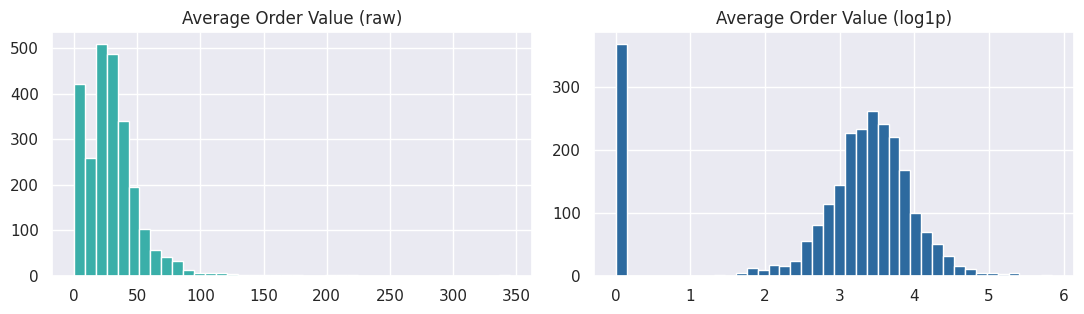

In [135]:
# 1. skew of avg_order_value (note: NaN for zero-order customers)
df['avg_order_value'] = df['avg_order_value'].fillna(0)

print('Skew before log-transform:', round(df['avg_order_value'].skew(), 2))

# 2. log-transform
df['avg_order_value_log'] = np.log1p(df['avg_order_value'])

# 3. compare skew before/after
print('Skew after log-transform :', round(df['avg_order_value_log'].skew(), 2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].hist(df['avg_order_value'], bins=40, color='#3AAFA9'); ax[0].set_title('Average Order Value (raw)')
ax[1].hist(df['avg_order_value_log'], bins=40, color='#2D6A9F'); ax[1].set_title('Average Order Value (log1p)')
plt.tight_layout(); plt.show()

In [136]:
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 40, 60, 200],
                         labels=['<25', '25-39', '40-59', '60+'])
print(df['age_group'].value_counts(dropna=False))

age_group
25-39    1025
40-59     872
<25       355
NaN       175
60+        73
Name: count, dtype: int64


In [137]:
# Define bins and labels for recency_days
bins = [0, 30, 90, df['recency_days'].max() + 1] # Max recency_days + 1 to ensure the last bin captures all values
labels = ['active', 'lapsing', 'dormant']

# Create the recency_group column
df['recency_group'] = pd.cut(df['recency_days'], bins=bins, labels=labels, right=False)

# Print counts per bucket
print("Counts per recency group:")
display(df['recency_group'].value_counts(dropna=False))

# Cross-tabulate recency_group against is_churned
print("\nCross-tabulation of Recency Group vs. Is Churned:")
display(pd.crosstab(df['recency_group'], df['is_churned']))

Counts per recency group:


,count
recency_group,
dormant,1510
lapsing,535
active,455



Cross-tabulation of Recency Group vs. Is Churned:


is_churned,0,1
recency_group,,
active,424,31
lapsing,507,28
dormant,1154,356


In [138]:
# tickets per order: a dissatisfaction signal, normalised by activity
df['tickets_per_order'] = df['support_tickets'] / df['frequency'].replace(0, np.nan)
df['tickets_per_order'] = df['tickets_per_order'].fillna(0)   # 0 orders -> 0

# spend per category: concentration of spend
df['spend_per_category'] = df['monetary'] / df['n_categories'].replace(0, np.nan)
df['spend_per_category'] = df['spend_per_category'].fillna(0)
print(df[['support_tickets', 'frequency', 'tickets_per_order',
          'monetary', 'n_categories', 'spend_per_category']].head())

   support_tickets  frequency  tickets_per_order  monetary  n_categories  \
0                2        0.0                0.0      0.00           0.0   
1                1        0.0                0.0      0.00           0.0   
2                1        1.0                1.0     39.17           1.0   
3                1        1.0                1.0      2.74           1.0   
4                0        4.0                0.0    133.80           3.0   

   spend_per_category  
0                0.00  
1                0.00  
2               39.17  
3                2.74  
4               44.60  


In [139]:
df['tenure_days'] = (SNAPSHOT - df['signup_date']).dt.days
df['tenure_months'] = df['tenure_days'] / 30

# Guard against zero tenure months for division
df['tenure_months'] = df['tenure_months'].replace(0, np.nan)

# Calculate orders_per_month
df['orders_per_month'] = df['frequency'] / df['tenure_months']

# Fill any NaN or infinite values (from division by zero) with 0
df['orders_per_month'] = df['orders_per_month'].fillna(0)
df['orders_per_month'] = df['orders_per_month'].replace([np.inf, -np.inf], 0)

Displaying the new `orders_per_month` column for the 5 customers with the highest `frequency`:

In [140]:
display(df.sort_values(by='frequency', ascending=False)[['customer_id', 'frequency', 'tenure_months', 'orders_per_month']].head())

,customer_id,frequency,tenure_months,orders_per_month
237,CUST00238,19.0,25.033333,0.758988
812,CUST00813,18.0,14.800000,1.216216
562,CUST00563,17.0,22.566667,0.753323
1918,CUST01919,16.0,24.233333,0.660248
1199,CUST01200,16.0,17.400000,0.919540


### Log-Transforming `total_spend`

Skew before log-transform: 1.73
Skew after log-transform : -1.12


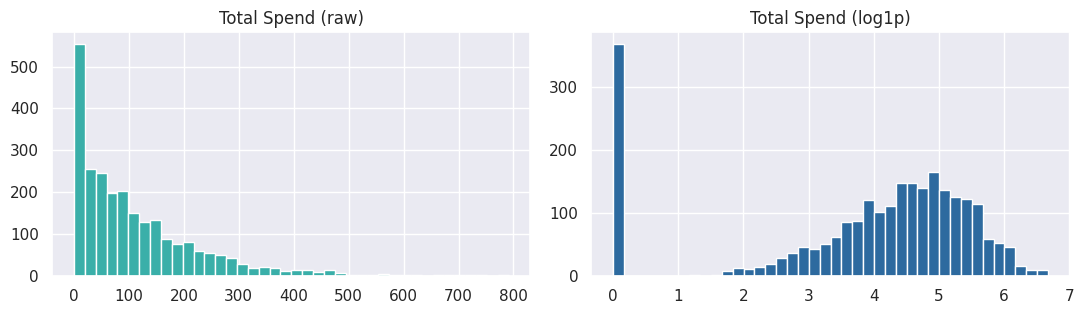

In [141]:
# Calculate skewness of 'total_spend' before log transformation
print('Skew before log-transform:', round(df['total_spend'].skew(), 2))

# Apply log1p transformation to 'total_spend'
df['total_spend_log'] = np.log1p(df['total_spend'])

# Calculate skewness of 'total_spend_log' after log transformation
print('Skew after log-transform :', round(df['total_spend_log'].skew(), 2))

# Visualize the distributions with histograms
fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].hist(df['total_spend'], bins=40, color='#3AAFA9'); ax[0].set_title('Total Spend (raw)')
ax[1].hist(df['total_spend_log'], bins=40, color='#2D6A9F'); ax[1].set_title('Total Spend (log1p)')
plt.tight_layout();
plt.show()

In [142]:
df['tenure_days'] = (SNAPSHOT - df['signup_date']).dt.days   # how long a customer
df['signup_month'] = df['signup_date'].dt.month
df['signup_dow'] = df['signup_date'].dt.dayofweek            # 0=Mon
df['signup_is_weekend'] = (df['signup_dow'] >= 5).astype(int)
# cyclical encoding so Dec(12) and Jan(1) are 'close', not far apart
df['month_sin'] = np.sin(2 * np.pi * df['signup_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['signup_month'] / 12)
df[['signup_date', 'tenure_days', 'signup_month',
    'signup_dow', 'signup_is_weekend', 'month_sin', 'month_cos']].head()

,signup_date,tenure_days,signup_month,signup_dow,signup_is_weekend,month_sin,month_cos
0,2021-04-19,1168,4,0,0,8.660254e-01,-5.000000e-01
1,2023-07-31,335,7,0,0,-5.000000e-01,-8.660254e-01
2,2023-03-07,481,3,1,0,1.000000e+00,6.123234e-17
3,2022-06-18,743,6,5,1,1.224647e-16,-1.000000e+00
4,2022-06-11,750,6,5,1,1.224647e-16,-1.000000e+00


In [143]:
# Calculate days_since_first_order
df['days_since_first_order'] = (SNAPSHOT - df['first_order_date']).dt.days

# Fill NaN values (for customers with no first_order_date) with 0
df['days_since_first_order'] = df['days_since_first_order'].fillna(0).astype(int)

# Display the new column alongside first_order_date for a few rows
print("Days since first order, with NaT handled:")
display(df[['customer_id', 'first_order_date', 'days_since_first_order']].head())

Days since first order, with NaT handled:


,customer_id,first_order_date,days_since_first_order
0,CUST00001,NaT,0
1,CUST00002,NaT,0
2,CUST00003,2023-05-22,405
3,CUST00004,2022-07-02,729
4,CUST00005,2022-09-18,651


In [144]:
df = pd.get_dummies(df, columns=['plan', 'device', 'payment_method'],
                    drop_first=False, dtype=int)
print('columns after one-hot:', df.shape[1])
print([c for c in df.columns if c.startswith(('plan_', 'device_'))])

columns after one-hot: 46
['plan_Basic', 'plan_Premium', 'plan_Standard', 'device_Desktop', 'device_Mobile', 'device_Tablet']


In [145]:
# keeps it to ONE numeric column = how common each city is.
freq = df['city'].value_counts(normalize=True)
df['city_freq'] = df['city'].map(freq).fillna(0)
print(df[['city', 'city_freq']].drop_duplicates().head(8))

          city  city_freq
0      Chennai   0.103265
1    Hyderabad   0.130612
2         Pune   0.082857
4       Mumbai   0.169796
5        Delhi   0.165306
10   Bengaluru   0.159184
13       Patna   0.013469
14  Coimbatore   0.016735
